<a href="https://colab.research.google.com/github/uttpald281-web/Data-Management/blob/main/Project%20Auto%20MPG%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Project 1 Auto MPG dataset analysis**



In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set a clean plot style
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = sns.load_dataset('mpg')

# Clean up historical brand name typos in the dataset
df['brand'] = df['name'].str.split().str[0].str.strip().str.lower()
brand_map = {
    'chevroelt': 'chevrolet',
    'chevy': 'chevrolet',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'toyouta': 'toyota',
    'maxda': 'mazda',
    'mercedes': 'mercedes-benz',
}
df['brand'] = df['brand'].replace(brand_map)
df = df.dropna()  # Drop rows with missing horsepower values

print(f"Dataset loaded: {df.shape[0]} cars analyzed across {df.shape[1]} technical specs.")

Dataset loaded: 392 cars analyzed across 10 technical specs.


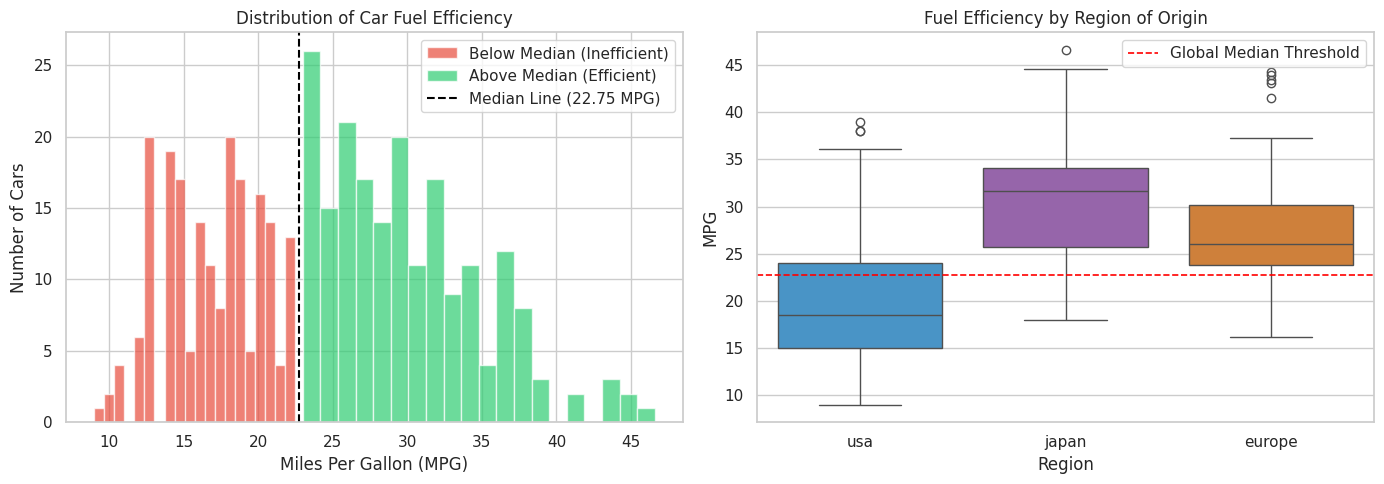

In [ ]:
median_mpg = df['mpg'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of MPG split by the median line
axes[0].hist(
    df[df['mpg'] < median_mpg]['mpg'],
    bins=20,
    color='#E74C3C',
    alpha=0.7,
    label='Below Median (Inefficient)',
    edgecolor='white',
)
axes[0].hist(
    df[df['mpg'] >= median_mpg]['mpg'],
    bins=20,
    color='#2ECC71',
    alpha=0.7,
    label='Above Median (Efficient)',
    edgecolor='white',
)
axes[0].axvline(
    median_mpg,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Median Line ({median_mpg:.2f} MPG)',
)
axes[0].set_xlabel('Miles Per Gallon (MPG)')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Car Fuel Efficiency')
axes[0].legend()

# Plot 2: Boxplot showing MPG by Regional Origin
sns.boxplot(
    data=df,
    x='origin',
    y='mpg',
    hue='origin',
    palette={'usa': '#3498DB', 'europe': '#E67E22', 'japan': '#9B59B6'},
    legend=False,
    ax=axes[1],
)
axes[1].axhline(
    median_mpg,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label='Global Median Threshold',
)
axes[1].set_title('Fuel Efficiency by Region of Origin')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('MPG')
axes[1].legend()

plt.tight_layout()
plt.show()

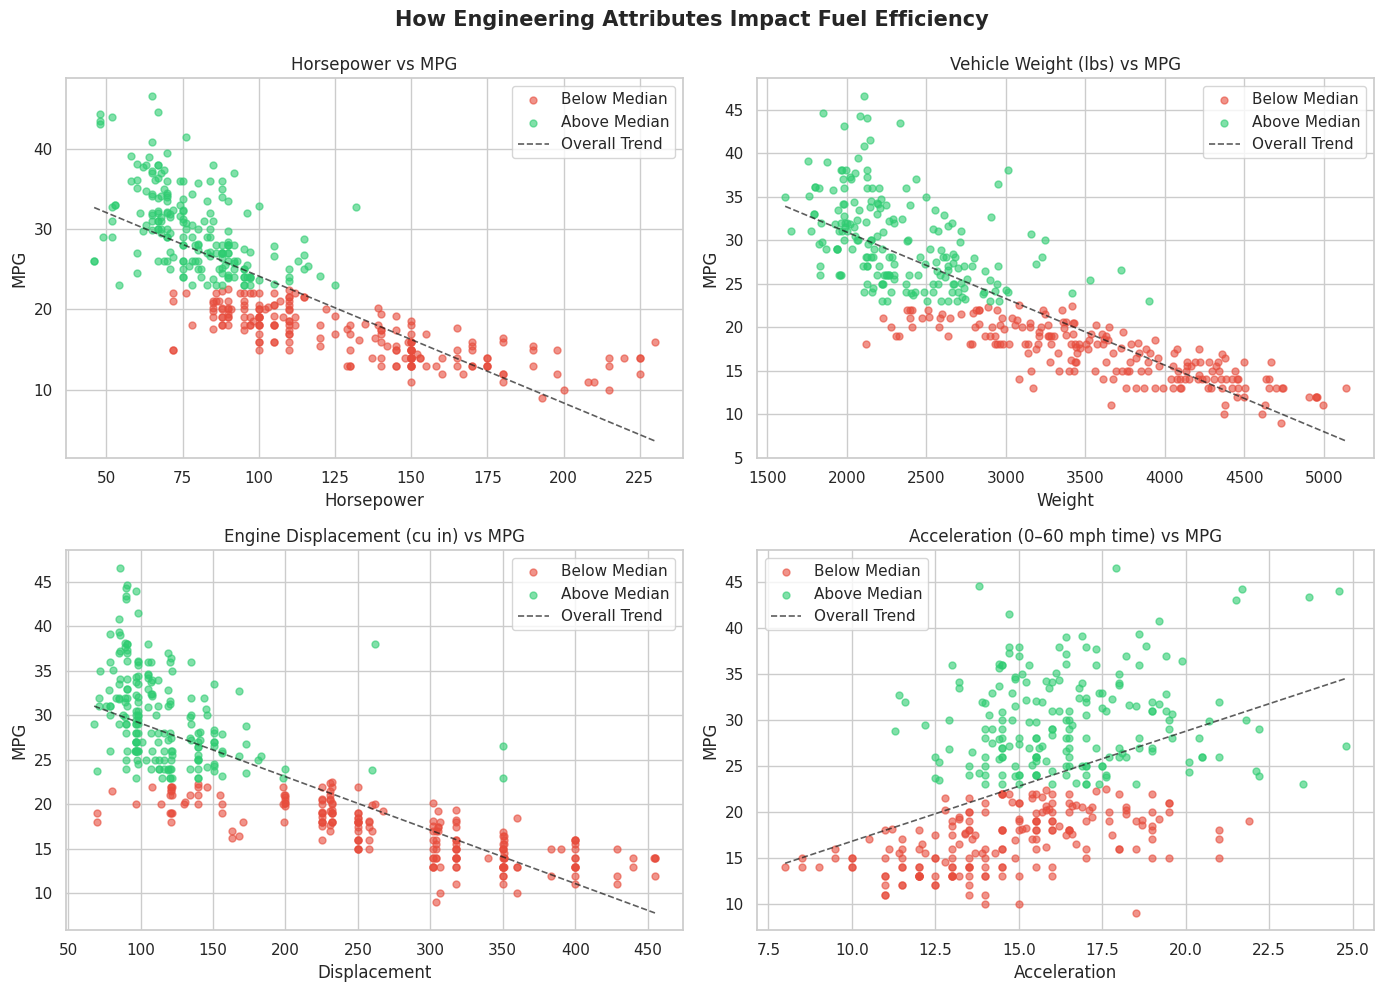

In [ ]:
features = ['horsepower', 'weight', 'displacement', 'acceleration']
titles = [
    'Horsepower vs MPG',
    'Vehicle Weight (lbs) vs MPG',
    'Engine Displacement (cu in) vs MPG',
    'Acceleration (0–60 mph time) vs MPG',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat, title in zip(axes, features, titles):
    # Scatter plot color-coded by whether it's above or below our median baseline
    above_median = df['mpg'] >= median_mpg
    ax.scatter(
        df[~above_median][feat],
        df[~above_median]['mpg'],
        color='#E74C3C',
        alpha=0.6,
        s=25,
        label='Below Median',
    )
    ax.scatter(
        df[above_median][feat],
        df[above_median]['mpg'],
        color='#2ECC71',
        alpha=0.6,
        s=25,
        label='Above Median',
    )

    # Simple trend line
    z = np.polyfit(df[feat], df['mpg'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.2, alpha=0.7, label='Overall Trend')

    ax.set_xlabel(feat.replace('_', ' ').capitalize())
    ax.set_ylabel('MPG')
    ax.set_title(title)
    ax.legend()

plt.suptitle(
    'How Engineering Attributes Impact Fuel Efficiency',
    fontsize=15,
    fontweight='bold',
    y=0.99,
)
plt.tight_layout()
plt.show()

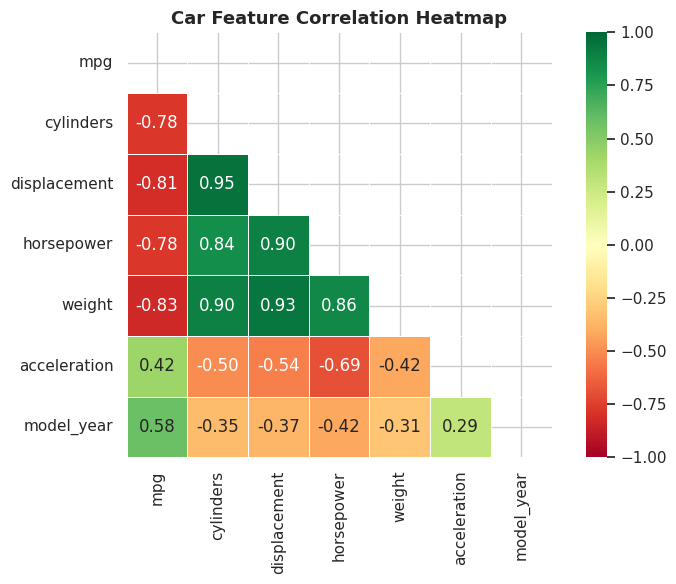

In [ ]:
num_cols = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
)
ax.set_title('Car Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

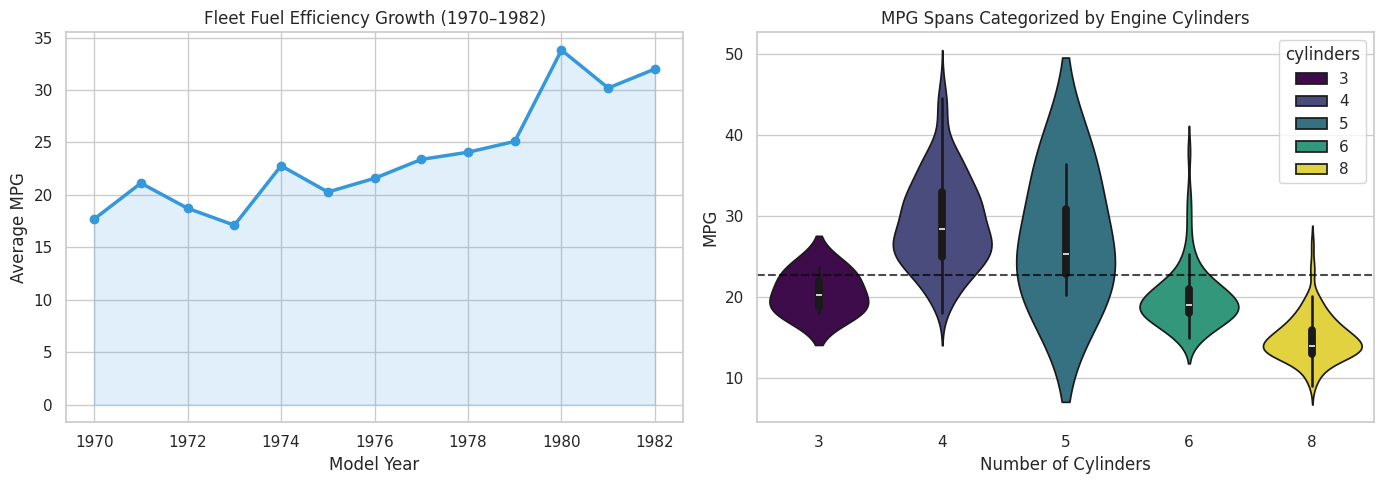

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Average MPG trend by year
year_mpg = df.groupby('model_year')['mpg'].mean().reset_index()
# Convert '70-'82 format to full 1970-1982 for clarity
year_mpg['actual_year'] = year_mpg['model_year'] + 1900

axes[0].plot(
    year_mpg['actual_year'],
    year_mpg['mpg'],
    marker='o',
    linewidth=2.5,
    color='#3498DB',
)
axes[0].fill_between(
    year_mpg['actual_year'], year_mpg['mpg'], alpha=0.15, color='#3498DB'
)
axes[0].set_xlabel('Model Year')
axes[0].set_ylabel('Average MPG')
axes[0].set_title('Fleet Fuel Efficiency Growth (1970–1982)')

# Right Plot: Performance by Cylinder Groupings
sns.violinplot(
    data=df, x='cylinders', y='mpg', hue='cylinders', palette='viridis', ax=axes[1]
)
axes[1].axhline(median_mpg, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('MPG Spans Categorized by Engine Cylinders')
axes[1].set_xlabel('Number of Cylinders')
axes[1].set_ylabel('MPG')

plt.tight_layout()
plt.show()

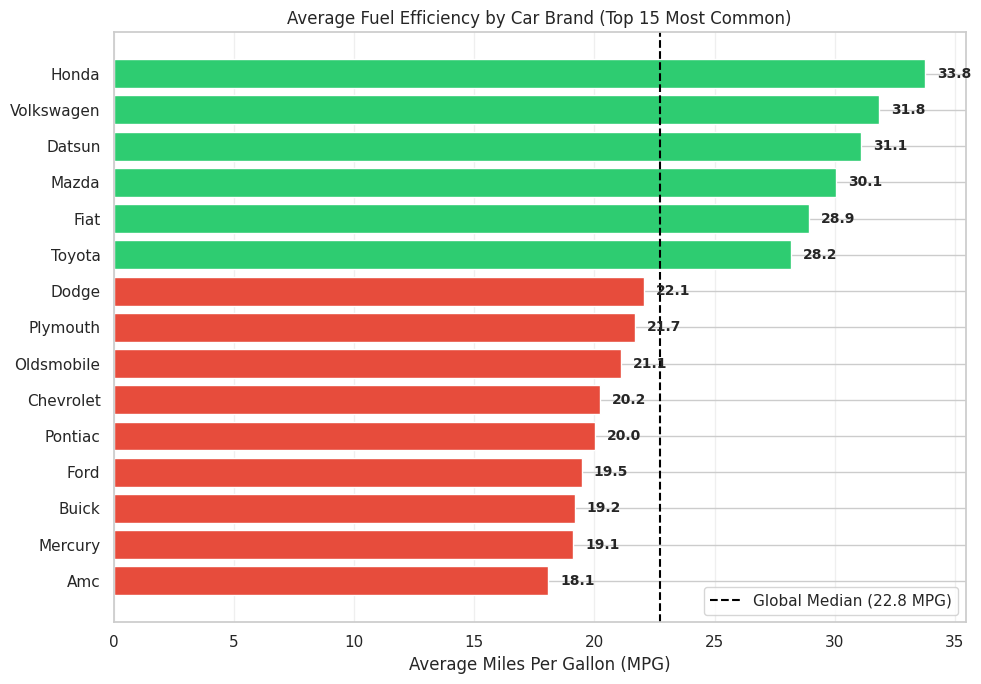

In [ ]:
# Get the top 15 most common brands in the dataset
top_brands = df['brand'].value_counts().head(15).index
brand_df = df[df['brand'].isin(top_brands)]

# Calculate average MPG per brand and sort
avg_mpg = brand_df.groupby('brand')['mpg'].mean().sort_values(ascending=True)

# Color code: Green if above the global median, Red if below
colors = ['#2ECC71' if val >= median_mpg else '#E74C3C' for val in avg_mpg.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(avg_mpg.index.str.capitalize(), avg_mpg.values, color=colors, edgecolor='white')

# Add the global median line for reference
ax.axvline(median_mpg, color='black', linestyle='--', linewidth=1.5,
           label=f'Global Median ({median_mpg:.1f} MPG)')

# Add data labels to the bars
for bar, val in zip(bars, avg_mpg.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Average Miles Per Gallon (MPG)')
ax.set_title('Average Fuel Efficiency by Car Brand (Top 15 Most Common)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

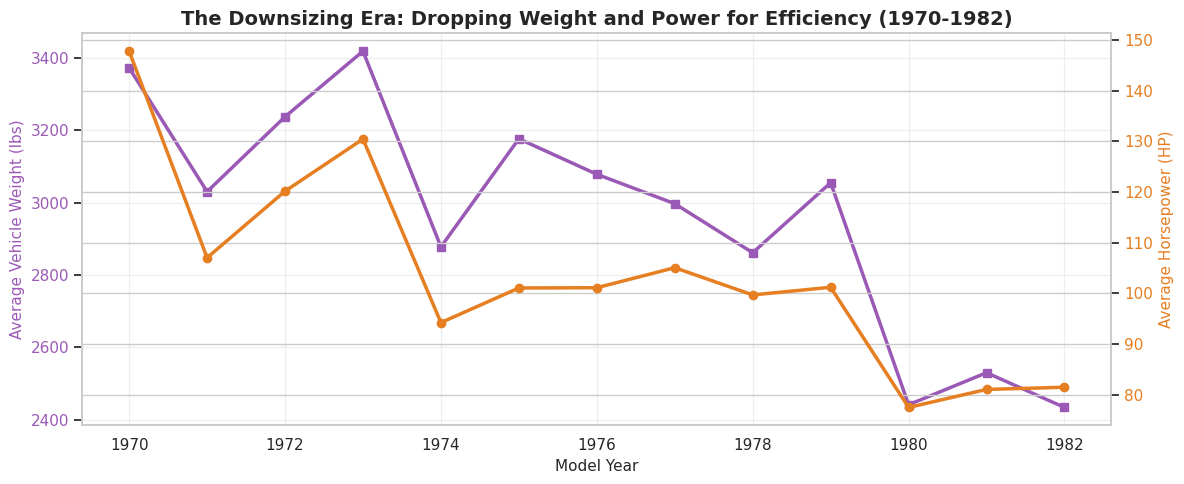

In [ ]:
# Group by year to get the average weight and horsepower
yearly_stats = df.groupby('model_year')[['weight', 'horsepower']].mean().reset_index()
yearly_stats['actual_year'] = yearly_stats['model_year'] + 1900

fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Average Weight on the left Y-axis
color1 = '#9B59B6'
ax1.plot(yearly_stats['actual_year'], yearly_stats['weight'], color=color1, marker='s', linewidth=2.5, label='Avg Weight (lbs)')
ax1.set_xlabel('Model Year', fontsize=11)
ax1.set_ylabel('Average Vehicle Weight (lbs)', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.3)

# Create a second Y-axis that shares the same X-axis for Horsepower
ax2 = ax1.twinx()
color2 = '#E67E22'
ax2.plot(yearly_stats['actual_year'], yearly_stats['horsepower'], color=color2, marker='o', linewidth=2.5, label='Avg Horsepower')
ax2.set_ylabel('Average Horsepower (HP)', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('The Downsizing Era: Dropping Weight and Power for Efficiency (1970-1982)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()